# Sustainability Aware Asset Management
## Group BB - Emerging Markets | Scope 1

---

**Matthieu Pagot, Aymen Laraoui, Cédric Nim, Rijad Talovic**

## Libraries & Configuration

We will use 4 different libraries in this project, pandas for data manipulation, numpy for numerical computation, matplotlib for plots and cvxpy for optimization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

All key parameters are centralized here for easy adjustment.

In [2]:
data_path = 'Data_2026/'

region = "EM"

low_prices_threshold = 0.5
stale_threshold = 0.5 # max proportion of zero returns allowed

lambda_shrink = 0.1

def prepare_covariance(Sigma, lam):
    Sigma_scaled = Sigma * 10_000
    diag = np.diag(np.diag(Sigma_scaled))
    Sigma_shrunk = (1 - lam) * Sigma_scaled + lam * diag
    eigvals, eigvecs = np.linalg.eigh(Sigma_shrunk)
    eigvals_clipped = np.maximum(eigvals, 0.0)
    Sigma_psd = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T
    return (Sigma_psd + Sigma_psd.T) / 2

---
# Part I - Standard Portfolio Allocation

## 1. Data Handling

### 1.1 Data Loading

In [3]:
static_file = pd.read_excel(f'{data_path}Static_2025.xlsx')
emerging_market_data = static_file[static_file['Region'] == region]

def load_data(file_name):
  data = pd.read_excel(f'{data_path}{file_name}')
  data = data.dropna(subset=['ISIN'])
  data = data[data['ISIN'].isin(emerging_market_data['ISIN'])]
  data = data.set_index('ISIN')
  data = data.drop(columns=['NAME'])
  data = data.loc[:, data.columns.notna()]
  data = data.apply(pd.to_numeric, errors='coerce')
  return data

Each data file is loaded and filtered to the Emerging Markets universe using the load_data function. The CO2 and revenue datasets are forward-filled along the year axis: if a company did not report emissions in year $Y$, the most recently available value is used instead. This follows the project guidelines and avoids dropping companies with occasional reporting gaps.

In [4]:
# return index
ri_monthly = load_data('DS_RI_T_USD_M_2025.xlsx')
ri_yearly = load_data('DS_RI_T_USD_Y_2025.xlsx')

# market cap
mv_monthly = load_data('DS_MV_T_USD_M_2025.xlsx')
mv_yearly = load_data('DS_MV_T_USD_Y_2025.xlsx')

# CO2 scope 1
co2_scope1 = load_data('DS_CO2_SCOPE_1_Y_2025.xlsx')
co2_scope1 = co2_scope1.ffill(axis=1) # forward-fill missing years

# revenues (thousands USD)
revenues = load_data('DS_REV_Y_2025.xlsx')
revenues = revenues.ffill(axis=1) # forward-fill missing years

print(static_file.columns.tolist())
print(emerging_market_data[['NAME', 'Country', 'Region']].head())

['ISIN', 'NAME', 'Country', 'Region']
                                   NAME Country Region
1                                 ALUAR      AR     EM
2                  BANCO BBVA ARGENTINA      AR     EM
3    TERNIUM ARGENTINA SOCIEDAD ANONIMA      AR     EM
117              CHINA YURUN FOOD GROUP      CN     EM
144                            AMBEV ON      BR     EM


The risk-free rate is a monthly U.S. T-bill rate stored in annualized form. It is converted to decimal form and indexed to month-end dates. When computing excess returns, the rate is lagged by one month so that $R_{f,t}$, known at the beginning of period $t+1$, is correctly matched to the portfolio return $R_{p,t+1}$.

In [5]:
rf_raw = pd.read_excel(f'{data_path}Risk_Free_Rate_2025.xlsx')
rf_raw.columns = ['Date', 'Risk Free Rate']
rf_raw['Date'] = pd.to_datetime(rf_raw['Date'].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
rf = rf_raw.set_index('Date')['Risk Free Rate'] / 100

### 1.2 Data Cleaning

Two cleaning steps are applied to the price series before computing returns:

1. **Low price filter**: any price below 0.5 USD is replaced by a missing value to remove obvious data errors.
2. **Interior forward-fill**: missing values between two valid prices are filled to handle reporting lags. We decided not to use a standard forward-fill, as it would also fill the trailing end of the series and create too many artificial values for stocks that have been delisted. To avoid this, we built our own function that only fills gaps within the series and leaves the trailing missing values untouched.

In [6]:
ri_monthly[ri_monthly < low_prices_threshold] = np.nan

def ffill_interior(df):
    result = df.copy()
    for isin in result.index:
        row = result.loc[isin]
        first_valid = row.first_valid_index()
        last_valid  = row.last_valid_index()
        if first_valid is None or last_valid is None:
            continue
        result.loc[isin, first_valid:last_valid] = (
            result.loc[isin, first_valid:last_valid].ffill()
        )
    return result

ri_monthly = ffill_interior(ri_monthly)

Monthly simple returns are computed from the cleaned price series:

$$R_{i,t} = \frac{P_{i,t} - P_{i,t-1}}{P_{i,t-1}}$$

If a stock has a valid price at $t-1$ but no price at $t$, it is assumed to have been delisted. In that case, its return is set to $-1$ (a total loss), which is consistent with the project guidelines.

In [7]:
prices = ri_monthly.copy()
returns = prices.pct_change(axis=1)

# handle delistings: set return to -100% when price disappears
cols = prices.columns
for i in range(1, len(cols)):
    prev_col = cols[i - 1]
    curr_col = cols[i]
    mask = prices[curr_col].isna() & prices[prev_col].notna()
    returns.loc[mask, curr_col] = -1.0

returns = returns.replace([np.inf, -np.inf], np.nan)

print(f"Returns shape: {returns.shape}")
print(f"Remaining inf values: {np.isinf(returns.values).sum()}")

Returns shape: (702, 314)
Remaining inf values: 0


This cell prints the dimensions and date range of each dataset as a quick verification before the portfolio construction.

In [8]:
objects = {
    "prices": prices,
    "returns": returns,
    "ri_yearly": ri_yearly,
    "mv_monthly": mv_monthly,
    "mv_yearly": mv_yearly,
    "co2_scope1": co2_scope1,
    "revenues": revenues,
}

for name, df in objects.items():
    print(f"{name} -> {df.shape} | {str(df.columns[0])[:10]} -> {str(df.columns[-1])[:10]}")

prices -> (702, 314) | 1999-12-31 -> 2026-01-30
returns -> (702, 314) | 1999-12-31 -> 2026-01-30
ri_yearly -> (702, 27) | 1999 -> 2025
mv_monthly -> (702, 314) | 1999-12-31 -> 2026-01-30
mv_yearly -> (702, 27) | 1999 -> 2025
co2_scope1 -> (702, 27) | 1999 -> 2025
revenues -> (702, 27) | 1999 -> 2025


## 2. Minimum-Variance Portfolio Allocation

### 2.1 Investment Set

For each investment year Y (from 2014 to 2024), we define the investable universe using data available at the end of Y-1. The main variables used are `emerging_market_data` (EM firms from the region filter), `eligible_isins` (EM ISINs with CO2 data reported at end of Y-1), `filtered_isins` (stocks passing the financial filters on history length, stale prices, and last valid price), and `filtered_carbon_isin_dict` (final dictionary `{year: [ISINs]}` passed to the optimizer).

In [9]:
filtered_carbon_isin_dict = {}

for year in range(2014, 2025):

    # 10-year rolling window ending at Y-1
    end_date = max(c for c in returns.columns if c.year == year - 1)
    end_idx = returns.columns.get_loc(end_date)
    window_cols = returns.columns[end_idx - 119 : end_idx + 1]

    # carbon filter: keep only ISINs with CO2 data for Y-1
    prev_year = year - 1
    eligible_isins = co2_scope1[prev_year].dropna().index.tolist()


    filtered_isins = []

    for isin in eligible_isins:
        if isin not in returns.index:
            continue
        returns_series = returns.loc[isin, window_cols]

        # filter A: at least 36 valid months out of 120
        has_enough_data = returns_series.notna().sum() >= 36

        # filter B: exclude stale price series
        has_stale_prices = (returns_series == 0.0).sum() / 120 > stale_threshold

        # filter C: valid last price
        last_price_valid = (isin in prices.index) and pd.notna(prices.loc[isin, end_date])

        # filter D: revenue and market cap available for Y-1
        has_rev = (isin in revenues.index  and pd.notna(revenues.loc[isin, prev_year]))
        has_cap = (isin in mv_yearly.index and pd.notna(mv_yearly.loc[isin, prev_year]))

        if has_enough_data and not has_stale_prices and last_price_valid and has_rev and has_cap:
            filtered_isins.append(isin)

    filtered_carbon_isin_dict[year] = filtered_isins

    print(f"Year {year} (window: {window_cols[0].date()} to {window_cols[-1].date()}):")
    print(f"  -> {len(filtered_isins)} stocks kept out of {len(eligible_isins)} eligible.")

Year 2014 (window: 2004-01-30 to 2013-12-31):
  -> 259 stocks kept out of 286 eligible.
Year 2015 (window: 2005-01-31 to 2014-12-31):
  -> 283 stocks kept out of 313 eligible.
Year 2016 (window: 2006-01-31 to 2015-12-31):
  -> 315 stocks kept out of 349 eligible.
Year 2017 (window: 2007-01-31 to 2016-12-30):
  -> 346 stocks kept out of 383 eligible.
Year 2018 (window: 2008-01-31 to 2017-12-29):
  -> 391 stocks kept out of 428 eligible.
Year 2019 (window: 2009-01-30 to 2018-12-31):
  -> 427 stocks kept out of 467 eligible.
Year 2020 (window: 2010-01-29 to 2019-12-31):
  -> 473 stocks kept out of 521 eligible.
Year 2021 (window: 2011-01-31 to 2020-12-31):
  -> 512 stocks kept out of 565 eligible.
Year 2022 (window: 2012-01-31 to 2021-12-31):
  -> 546 stocks kept out of 603 eligible.
Year 2023 (window: 2013-01-31 to 2022-12-30):
  -> 578 stocks kept out of 643 eligible.
Year 2024 (window: 2014-01-31 to 2023-12-29):
  -> 584 stocks kept out of 654 eligible.


### 2.1.2 Covariance Matrix Estimation

The covariance matrix is estimated using the pairwise correlation method from Course 5, which is designed to handle stocks with different listing histories:

$$\hat{\sigma}_{ij} = \hat{\rho}_{ij} \cdot \hat{\sigma}_i \cdot \hat{\sigma}_j$$

where $\hat{\sigma}_i$ is the standard deviation of asset $i$ over its full 120-month window, and $\hat{\rho}_{ij}$ is the correlation computed only over months where both $i$ and $j$ have valid returns.

Two adjustments are then applied before passing the matrix to the solver:
- **Diagonal shrinkage** toward the identity: $\tilde{\Sigma} = (1-\lambda)\hat{\Sigma} + \lambda \cdot \mathrm{diag}(\hat{\Sigma})$ with $\lambda = 0.1$
- **PSD projection**: negative eigenvalues are set to zero to ensure the matrix is positive semi-definite

In [10]:
covariance_matrices = {}

for year in range(2014, 2025):

    end_date = max(c for c in returns.columns if c.year == year - 1)
    end_idx = returns.columns.get_loc(end_date)
    window_cols = returns.columns[end_idx - 119 : end_idx + 1]

    isins = filtered_carbon_isin_dict[year]
    N = len(isins)

    ret_df = returns.loc[isins, window_cols].T

    global_means = ret_df.mean()
    global_stds = ret_df.std(ddof=1)

    ret_centered = ret_df - global_means

    X = ret_centered.fillna(0.0).values
    M = ret_centered.notna().astype(float).values

    numerator = X.T @ X

    X_sq = X ** 2
    sum_sq_i = X_sq.T @ M
    sum_sq_j = M.T @ X_sq
    denominator = np.sqrt(sum_sq_i * sum_sq_j)

    rho = np.where(denominator > 0, numerator / denominator, 0.0)
    np.fill_diagonal(rho, 1.0)

    stds_matrix = np.outer(global_stds.values, global_stds.values)
    sigma = rho * stds_matrix
    sigma = np.nan_to_num(sigma, nan=0.0)

    covariance_matrices[year] = sigma
    print(f"Year {year}: {N}x{N} covariance matrix computed")

Year 2014: 259x259 covariance matrix computed
Year 2015: 283x283 covariance matrix computed
Year 2016: 315x315 covariance matrix computed
Year 2017: 346x346 covariance matrix computed
Year 2018: 391x391 covariance matrix computed
Year 2019: 427x427 covariance matrix computed
Year 2020: 473x473 covariance matrix computed
Year 2021: 512x512 covariance matrix computed
Year 2022: 546x546 covariance matrix computed
Year 2023: 578x578 covariance matrix computed
Year 2024: 584x584 covariance matrix computed


### 2.2 Minimum-Variance Portfolio

The MVP is obtained by solving the following quadratic program for each investment year $Y$:

$$\min_{w} \; w^\top \tilde{\Sigma} \, w$$

subject to:
$$\sum_i w_i = 1, \qquad w_i \geq 0 \quad \forall i$$

where $\tilde{\Sigma}$ is the shrunk and PSD-corrected covariance matrix. The long-only constraint prevents short positions. The optimization is solved with CLARABEL, the default solver in cvxpy.

In [11]:
unconstrained_weights_shrink = {}

for year in range(2014, 2025):

    isins = filtered_carbon_isin_dict[year]
    n = len(isins)
    Sigma = covariance_matrices[year]

    Sigma_psd_np = prepare_covariance(Sigma, lambda_shrink)

    w = cp.Variable(n)
    objective = cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sigma_psd_np)))
    constraints = [
        cp.sum(w) == 1,
        w >= 0  # long-only
    ]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=False)

    if prob.status in ("optimal", "optimal_inaccurate"):
        weights = pd.Series(w.value, index=isins)
        weights = weights.clip(lower=0)  # remove small negative numerical artifacts
        weights /= weights.sum()
        unconstrained_weights_shrink[year] = weights
        print(f"{year}: OK | max weight={weights.max():.2%}, stocks w>0.3%: {(weights > 0.003).sum()}/{n}")
    else:
        print(f"{year}: failed ({prob.status})")

2014: OK | max weight=24.17%, stocks w>0.3%: 19/259
2015: OK | max weight=31.81%, stocks w>0.3%: 15/283
2016: OK | max weight=28.00%, stocks w>0.3%: 18/315
2017: OK | max weight=34.50%, stocks w>0.3%: 19/346
2018: OK | max weight=26.36%, stocks w>0.3%: 29/391
2019: OK | max weight=30.41%, stocks w>0.3%: 29/427
2020: OK | max weight=26.63%, stocks w>0.3%: 25/473
2021: OK | max weight=36.34%, stocks w>0.3%: 24/512
2022: OK | max weight=30.11%, stocks w>0.3%: 24/546
2023: OK | max weight=22.92%, stocks w>0.3%: 34/578
2024: OK | max weight=20.31%, stocks w>0.3%: 29/584


### 2.2.1 Ex-Post Simulation with Weight Drift

At the start of each year, weights are fixed and then evolve without rebalancing over the 12 months. The weight drift formula from the project PDF is:

$$w_{i,t+1} = \frac{w_{i,t}(1 + R_{i,t+1})}{1 + R_{p,t+1}}$$

where $R_{p,t+1} = \sum_i w_{i,t} R_{i,t+1}$ is the portfolio return at month $t+1$. This reflects the natural change in portfolio composition as prices move between two rebalancing dates.

In [12]:
weights_df = pd.DataFrame(unconstrained_weights_shrink).fillna(0.0)

print("Top 5 weights for 2014:")
print(weights_df[2014].nlargest(5))


Top 5 weights for 2014:
TW0002412004    0.241718
MYL4162OO003    0.222360
TW0003045001    0.089034
ID1000094006    0.078987
MYL5681OO001    0.061653
Name: 2014, dtype: float64


In [13]:
portfolio_returns = []

for year in range(2014, 2025):

    w = weights_df[year].copy()
    w = w.reindex(returns.index).fillna(0.0)
    w /= w.sum()

    months = [dt for dt in returns.columns if dt.year == year]

    for t in sorted(months):
        r_t = returns[t].reindex(w.index).fillna(0.0)
        R_p = np.dot(w.values, r_t.values)
        portfolio_returns.append((t, R_p))

        # weight drift
        w = w * (1 + r_t) / (1 + R_p)
        w /= w.sum()

pf_ret_mvp = pd.Series(
    [ret for (_, ret) in portfolio_returns],
    index=[dt for (dt, _) in portfolio_returns],
    name="MVP_ExPost_Returns"
)

print(f"Months simulated: {len(pf_ret_mvp)}")
print(f"Mean monthly return: {pf_ret_mvp.mean():.4%}")

Months simulated: 132
Mean monthly return: 0.4913%


### 2.2.2 Performance Metrics

The following statistics are computed over the 2014-2024 period ($T = 132$ months). The annualized return is $\left(\prod_{t=1}^{T}(1+R_{p,t})\right)^{12/T} - 1$, the annualized volatility is $\hat{\sigma}_{\text{monthly}} \times \sqrt{12}$, and the Sharpe ratio is $\dfrac{\overline{R^e}}{\hat{\sigma}_{\text{monthly}}} \times \sqrt{12}$.

The excess return is defined as $R^e_{t+1} = R_{p,t+1} - R_{f,t}$, where $R_{f,t}$ is the risk-free rate known at the start of period $t+1$.

In [14]:
rf_series = rf.shift(1).reindex(pf_ret_mvp.index)

mean_monthly   = pf_ret_mvp.mean()
ann_return     = ((1 + pf_ret_mvp).prod()) ** (12 / len(pf_ret_mvp)) - 1

sigma_monthly  = pf_ret_mvp.std(ddof=1)
ann_volatility = sigma_monthly * np.sqrt(12)

excess_ret = pf_ret_mvp - rf_series
ann_sharpe = (excess_ret.mean() / sigma_monthly) * np.sqrt(12)

min_ret = pf_ret_mvp.min()
max_ret = pf_ret_mvp.max()

metrics_df = pd.DataFrame({
    "Minimum Variance Portfolio (MVP)": [
        f"{ann_return:.3%}",
        f"{ann_volatility:.3%}",
        f"{ann_sharpe:.3f}",
        f"{min_ret:.3%}",
        f"{max_ret:.3%}"
    ]
}, index=["Annualized Average Return",
          "Annualized Volatility",
          "Sharpe Ratio",
          "Minimum Monthly Return",
          "Maximum Monthly Return"])

print(metrics_df)

                          Minimum Variance Portfolio (MVP)
Annualized Average Return                           5.562%
Annualized Volatility                               9.816%
Sharpe Ratio                                         0.500
Minimum Monthly Return                             -6.067%
Maximum Monthly Return                             12.793%


### 2.3 Value-Weighted Portfolio

The value-weighted portfolio assigns each stock a weight proportional to its market capitalization at the end of the previous month:

$$w_{i,t}^{VW} = \frac{\mathrm{Cap}_{i,t-1}}{\sum_{j} \mathrm{Cap}_{j,t-1}}$$

where the sum runs over all stocks in the eligible universe for year $Y$. This benchmark replicates a passive cap-weighted index strategy.

In [15]:
mcap = mv_monthly.copy()

ret_cols = pd.to_datetime(returns.columns)
mcap.columns = pd.to_datetime(mcap.columns)

all_months = ret_cols[(ret_cols.year >= 2014) & (ret_cols.year <= 2024)]
mcap_date_lookup = {(c.year, c.month): c for c in mcap.columns}

vw_weights = pd.DataFrame(0.0, index=mcap.index, columns=all_months)

for year in range(2014, 2025):
    filtered = filtered_carbon_isin_dict.get(year, [])
    if not filtered:
        continue

    months = [m for m in all_months if m.year == year]

    for m in months:
        prev_y = m.year if m.month > 1 else m.year - 1
        prev_m = m.month - 1 if m.month > 1 else 12
        prev_month = mcap_date_lookup.get((prev_y, prev_m))

        if prev_month is None:
            continue

        caps = mcap[prev_month].reindex(filtered)
        total = caps.sum(skipna=True)
        if np.isnan(total):
            continue

        w = (caps / total).fillna(0.0)
        vw_weights.loc[filtered, m] = w.values

jan_2014 = next(m for m in all_months if m.year == 2014 and m.month == 1)
print(f"Weight sum Jan 2014: {vw_weights[jan_2014].sum():.4f}")
print(f"Stocks with VW weight > 0: {(vw_weights[jan_2014] > 0).sum()} / {len(filtered_carbon_isin_dict[2014])}")

Weight sum Jan 2014: 1.0000
Stocks with VW weight > 0: 259 / 259


In [16]:
common_months = returns.columns.intersection(vw_weights.columns)

W = vw_weights[common_months].fillna(0.0)
R = returns[common_months].fillna(0.0)

pf_vw_ret = (W * R).sum()
pf_vw_ret.name = "VW_ExPost_Returns"

rf_series_vw = rf.shift(1).reindex(pf_vw_ret.index)

mean_monthly_vw = pf_vw_ret.mean()
ann_return_vw = ((1 + pf_vw_ret).prod()) ** (12 / len(pf_vw_ret)) - 1

sigma_monthly_vw = pf_vw_ret.std(ddof=1)
ann_volatility_vw = sigma_monthly_vw * np.sqrt(12)

excess_ret_vw = pf_vw_ret - rf_series_vw
ann_sharpe_vw = (excess_ret_vw.mean() / sigma_monthly_vw) * np.sqrt(12)

min_ret_vw = pf_vw_ret.min()
max_ret_vw = pf_vw_ret.max()

metrics_vw_df = pd.DataFrame({
    "Value-Weighted Portfolio (VW)": [
        f"{ann_return_vw:.3%}",
        f"{ann_volatility_vw:.3%}",
        f"{ann_sharpe_vw:.3f}",
        f"{min_ret_vw:.3%}",
        f"{max_ret_vw:.3%}"
    ]
}, index=["Annualized Average Return",
          "Annualized Volatility",
          "Sharpe Ratio",
          "Minimum Monthly Return",
          "Maximum Monthly Return"])

print(metrics_vw_df)

                          Value-Weighted Portfolio (VW)
Annualized Average Return                        5.284%
Annualized Volatility                           16.043%
Sharpe Ratio                                      0.358
Minimum Monthly Return                         -16.687%
Maximum Monthly Return                          13.366%


### 2.4 Results Comparison: MVP vs. Value-Weighted Portfolio

Cumulative returns are rebased to 1 at the end of 2013. The annualized cumulative return (CAGR) is given by:

$$\mathrm{CAGR} = \left(\prod_{t=1}^{T}(1+R_{p,t})\right)^{12/T} - 1$$

Results are exported to SAAM_Part1_Export.xlsx with two sheets: one for the summary metrics and one for the monthly returns.

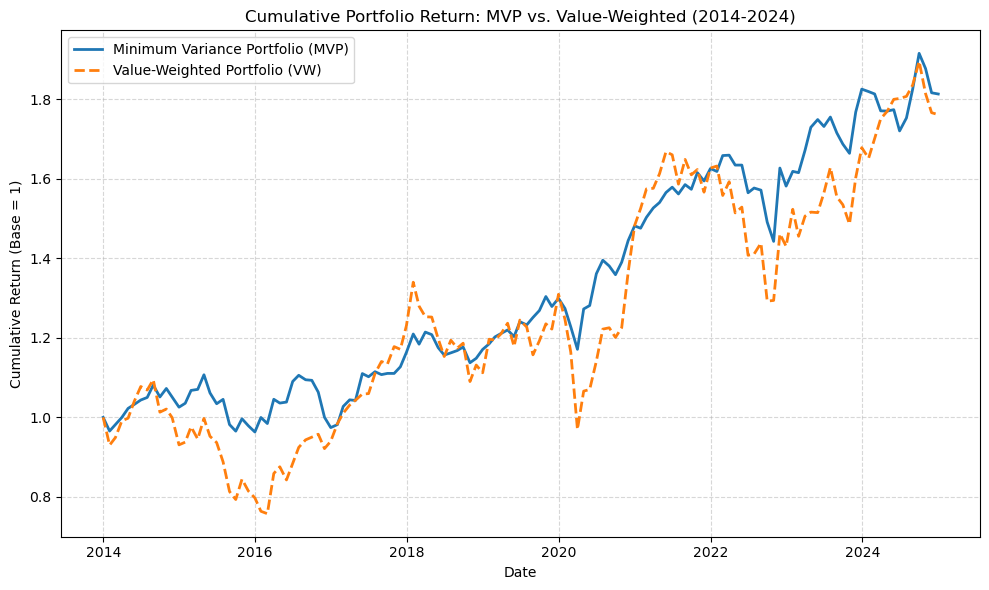

                                     Value-Weighted Portfolio (VW)  \
Annualized Average Return                                   0.0528   
Annualized Volatility                                       0.1604   
Annualized Cumulative Return (CAGR)                         0.0528   
Sharpe Ratio                                                0.3575   
Minimum Monthly Return                                     -0.1669   
Maximum Monthly Return                                      0.1337   

                                     Minimum Variance Portfolio (MVP)  
Annualized Average Return                                      0.0556  
Annualized Volatility                                          0.0982  
Annualized Cumulative Return (CAGR)                            0.0556  
Sharpe Ratio                                                   0.5002  
Minimum Monthly Return                                        -0.0607  
Maximum Monthly Return                                         0.1279  
SAAM_

In [17]:
cumret_mvp = pd.concat([pd.Series({pd.Timestamp("2013-12-31"): 1.0}), (1 + pf_ret_mvp).cumprod()])
cumret_vw = pd.concat([pd.Series({pd.Timestamp("2013-12-31"): 1.0}), (1 + pf_vw_ret).cumprod()])

plt.figure(figsize=(10, 6))
plt.plot(cumret_mvp.index, cumret_mvp.values, label="Minimum Variance Portfolio (MVP)", color='tab:blue', linewidth=2)
plt.plot(cumret_vw.index, cumret_vw.values, label="Value-Weighted Portfolio (VW)", color='tab:orange', linewidth=2, linestyle="--")
plt.title("Cumulative Portfolio Return: MVP vs. Value-Weighted (2014-2024)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Base = 1)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

T = len(pf_ret_mvp)  # 132 months
ann_cum_ret_mvp = (cumret_mvp.iloc[-1]) ** (12 / T) - 1
ann_cum_ret_vw = (cumret_vw.iloc[-1]) ** (12 / T) - 1

comparison_df = pd.DataFrame({
    "Value-Weighted Portfolio (VW)": [
        ann_return_vw,
        ann_volatility_vw,
        ann_cum_ret_vw,
        ann_sharpe_vw,
        min_ret_vw,
        max_ret_vw
    ],
    "Minimum Variance Portfolio (MVP)": [
        ann_return,
        ann_volatility,
        ann_cum_ret_mvp,
        ann_sharpe,
        min_ret,
        max_ret
    ]
}, index=[
    "Annualized Average Return",
    "Annualized Volatility",
    "Annualized Cumulative Return (CAGR)",
    "Sharpe Ratio",
    "Minimum Monthly Return",
    "Maximum Monthly Return"
])

print(comparison_df.round(4))

export_returns = pd.DataFrame({
    "Value-Weighted Portfolio": pf_vw_ret,
    "Minimum Variance Portfolio": pf_ret_mvp
})

with pd.ExcelWriter("SAAM_Part1_Export.xlsx") as writer:
    comparison_df.to_excel(writer, sheet_name="Metrics")
    export_returns.to_excel(writer, sheet_name="Monthly_Returns")

print("SAAM_Part1_Export.xlsx saved.")

---
# Part II - Portfolio Allocation with Carbon Emission Reduction

## 3. Allocation with a 50% Reduction in Carbon Emissions

### 3.1 Carbon Emissions Metrics

Two carbon metrics are computed each year for each portfolio, based on Scope 1 CO2 emissions from year $Y-1$:

**Weighted-Average Carbon Intensity (WACI)** measures carbon efficiency relative to revenues:
$$\mathrm{WACI} = \sum_{i} w_i \cdot \frac{E_i}{\mathrm{Rev}_i}$$

**Carbon Footprint (CF)** measures carbon exposure per million dollars invested:
$$\mathrm{CF} = \sum_{i} w_i \cdot \frac{E_i}{\mathrm{Cap}_i}$$

where $E_i$ is Scope 1 CO2 emissions in tCO2, $\mathrm{Rev}_i$ is revenue in million USD, and $\mathrm{Cap}_i$ is market capitalization in million USD.


Top 10 WACI contributors (MVP, 2024 allocation, 2023 data):
                                  NAME Country Contribution_WACI Weight_MVP Carbon_Intensity
PEP702101002        ENGIE ENERGIA PERU      PE            164.17      3.24%          5067.31
RU000A0JPKH7     FED.HYGN.CO. RUSHYDRO      RU            126.12      2.49%          5060.57
PHY5764J1483           MANILA ELECTRIC      PH             64.02      4.93%          1297.41
PK0053401011  FAUJI FERTILIZER COMPANY      PK             53.90      1.33%          4038.45
CNE1000002S8   COSCO SHIP.EN.TRSP. 'H'      CN             41.95      3.27%          1283.89
INE059A01026                     CIPLA      IN              5.90      2.47%           238.65
RU000A0DKVS5                   NOVATEK      RU              5.81      1.01%           576.29
PEP700511004               ORYGEN PERU      PE              4.59      0.14%          3238.66
PHY0005M1090             ABOITIZ POWER      PH              3.61      2.24%           161.17
INE361B01

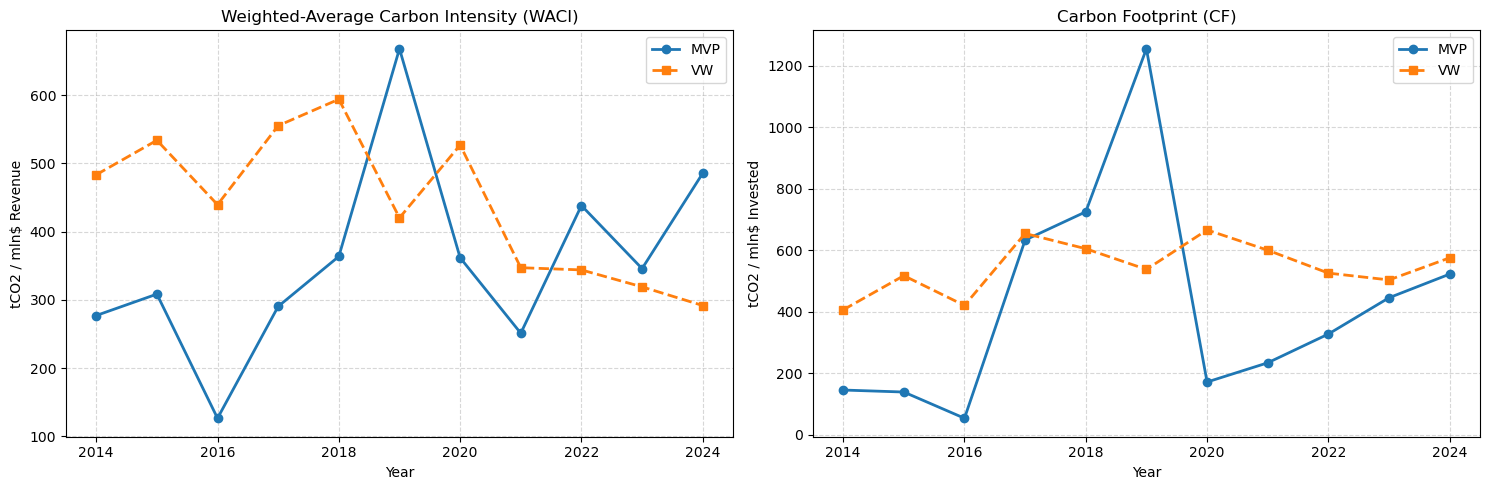

      WACI MVP  WACI VW   CF MVP   CF VW
2014    277.04   483.43   146.07  406.71
2015    308.42   533.93   139.58  517.89
2016    126.42   439.53    54.32  421.02
2017    290.35   555.33   633.71  655.01
2018    363.68   594.09   725.52  605.49
2019    668.06   420.25  1255.45  538.21
2020    361.78   526.99   172.13  666.54
2021    251.10   347.14   234.59  600.74
2022    438.29   343.90   328.11  526.18
2023    345.82   319.06   446.07  504.02
2024    485.64   291.71   522.95  575.93


In [18]:
waci_mvp, cf_mvp = {}, {}
waci_vw, cf_vw = {}, {}
top_polluters_mvp = None

for year in range(2014, 2025):
    prev_year = year - 1
    isins = filtered_carbon_isin_dict[year]

    E_i = co2_scope1.loc[isins, prev_year]          # tCO2
    Rev_i = revenues.loc[isins, prev_year] / 1000.0  # millions USD
    Cap_i = mv_yearly.loc[isins, prev_year]          # millions USD

    CI_i = (E_i / Rev_i).replace([np.inf, -np.inf], np.nan)

    w_mvp = unconstrained_weights_shrink[year].reindex(isins).fillna(0.0)
    w_mvp = w_mvp / w_mvp.sum()

    w_vw = Cap_i.fillna(0.0) / Cap_i.fillna(0.0).sum()

    waci_mvp[year] = (w_mvp * CI_i).sum()
    waci_vw[year] = (w_vw * CI_i).sum()

    cf_mvp[year] = (w_mvp * (E_i / Cap_i)).sum()
    cf_vw[year] = (w_vw * (E_i / Cap_i)).sum()

    # top 10 WACI contributors for 2024
    if year == 2024:
        contributions = (w_mvp * CI_i).dropna()
        top_10_isins = contributions.nlargest(10).index
        static_indexed = static_file.set_index('ISIN')
        top_polluters_mvp = static_indexed.loc[top_10_isins, ['NAME', 'Country']].copy()
        top_polluters_mvp['Contribution_WACI'] = contributions.loc[top_10_isins]
        top_polluters_mvp['Weight_MVP'] = w_mvp.loc[top_10_isins]
        top_polluters_mvp['Carbon_Intensity'] = CI_i.loc[top_10_isins]

waci_mvp = pd.Series(waci_mvp, name="MVP WACI")
cf_mvp = pd.Series(cf_mvp, name="MVP CF")
waci_vw = pd.Series(waci_vw, name="VW WACI")
cf_vw = pd.Series(cf_vw, name="VW CF")

print("\nTop 10 WACI contributors (MVP, 2024 allocation, 2023 data):")
print(top_polluters_mvp.to_string(formatters={
    'Contribution_WACI': '{:.2f}'.format,
    'Weight_MVP':        '{:.2%}'.format,
    'Carbon_Intensity':  '{:.2f}'.format
}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(waci_mvp.index, waci_mvp.values, label='MVP', color='tab:blue', marker='o', linewidth=2)
axes[0].plot(waci_vw.index, waci_vw.values, label='VW', color='tab:orange', marker='s', linewidth=2, linestyle='--')
axes[0].set_title('Weighted-Average Carbon Intensity (WACI)')
axes[0].set_ylabel('tCO2 / mln$ Revenue')
axes[0].set_xlabel('Year')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(cf_mvp.index, cf_mvp.values, label='MVP', color='tab:blue', marker='o', linewidth=2)
axes[1].plot(cf_vw.index, cf_vw.values, label='VW', color='tab:orange', marker='s', linewidth=2, linestyle='--')
axes[1].set_title('Carbon Footprint (CF)')
axes[1].set_ylabel('tCO2 / mln$ Invested')
axes[1].set_xlabel('Year')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame({
    "WACI MVP": waci_mvp,
    "WACI VW":  waci_vw,
    "CF MVP":   cf_mvp,
    "CF VW":    cf_vw,
})

print(summary_df.round(2).to_string())

### 3.2 Carbon-Constrained MVP

This portfolio adds a carbon footprint constraint to the standard MVP problem:

$$\min_{w} \; w^\top \tilde{\Sigma} \, w$$

subject to:
$$\sum_i w_i = 1, \quad w_i \geq 0, \quad \sum_i w_i \cdot \frac{E_i}{\mathrm{Cap}_i} \leq 0.5 \times \mathrm{CF}^{mv}_{Y}$$

The carbon budget is set at 50% of the unconstrained MVP carbon footprint each year, which forces the optimizer to reduce exposure to high-emission stocks.

2014: CF = 73.03 (target 73.03)
2015: CF = 69.79 (target 69.79)
2016: CF = 27.16 (target 27.16)
2017: CF = 316.85 (target 316.85)
2018: CF = 362.76 (target 362.76)
2019: CF = 627.73 (target 627.73)
2020: CF = 86.06 (target 86.06)
2021: CF = 117.29 (target 117.29)
2022: CF = 164.06 (target 164.06)
2023: CF = 223.03 (target 223.03)
2024: CF = 261.48 (target 261.48)
                      MVP Standard (P mv) Green MVP (P mv 0.5)
Annualized Return                  5.562%               5.458%
Annualized Volatility              9.816%               9.748%
Sharpe Ratio                        0.500                0.462

Top 5 stocks most reduced by the carbon constraint (2024 allocation):
- ENGIE ENERGIA PERU (weight reduction: 2.62%)
- FED.HYGN.CO. RUSHYDRO (weight reduction: 1.44%)
- FAUJI FERTILIZER COMPANY (weight reduction: 1.33%)
- MANILA ELECTRIC (weight reduction: 1.08%)
- COSCO SHIP.EN.TRSP. 'H' (weight reduction: 0.66%)


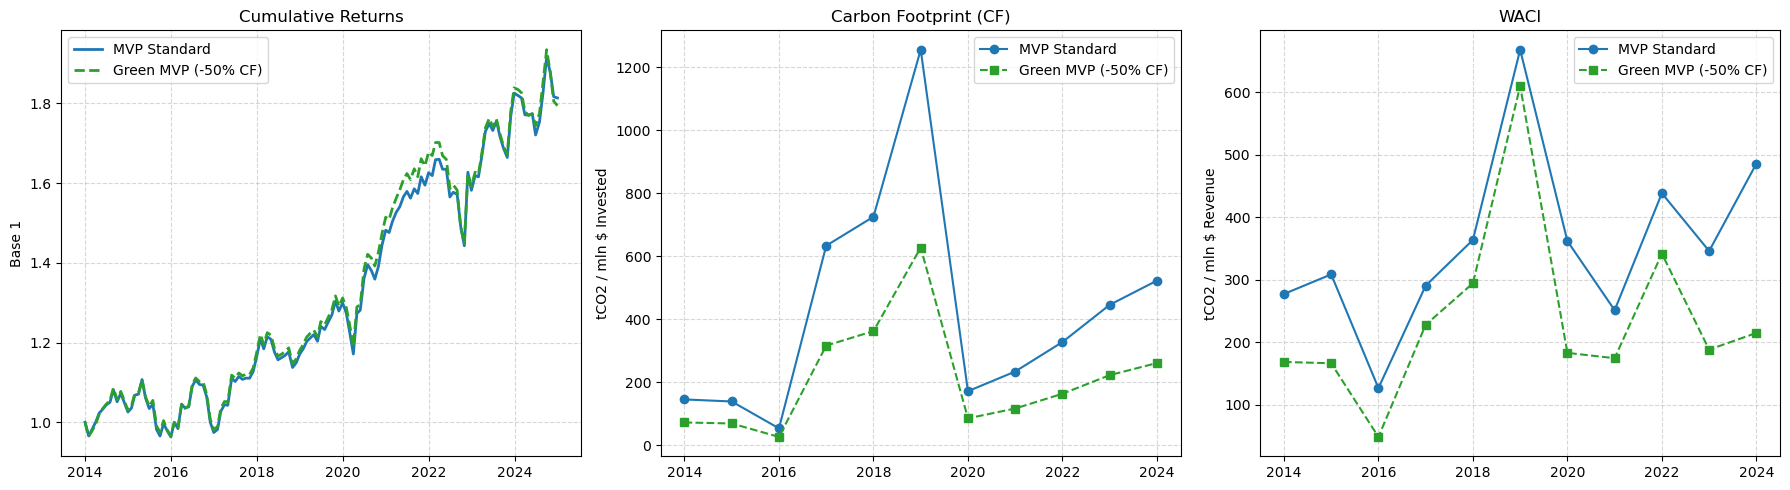

In [19]:
constrained_weights_dict = {}

for year in range(2014, 2025):
    prev_year = year - 1
    isins = filtered_carbon_isin_dict[year]
    N = len(isins)

    E_i = co2_scope1.loc[isins, prev_year]
    Cap_i = mv_yearly.loc[isins, prev_year]

    c_vector = (E_i / Cap_i).fillna(0.0).values
    cf_target = 0.5 * cf_mvp[year]

    Sigma_psd_np = prepare_covariance(covariance_matrices[year], lambda_shrink)

    w = cp.Variable(N)
    objective = cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sigma_psd_np)))
    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        c_vector @ w <= cf_target
    ]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=False)

    if prob.status in ("optimal", "optimal_inaccurate"):
        weights = pd.Series(w.value, index=isins)
        weights = weights.clip(lower=0)
        weights /= weights.sum()
        constrained_weights_dict[year] = weights
        cf_achieved = np.dot(c_vector, weights.values)
        print(f"{year}: CF = {cf_achieved:.2f} (target {cf_target:.2f})")
    else:
        print(f"{year}: failed ({prob.status})")

weights_c_df = pd.DataFrame(constrained_weights_dict).fillna(0.0)

# ex-post simulation with weight drift
portfolio_returns_c = []

for year in range(2014, 2025):
    w = weights_c_df[year].copy()
    w = w.reindex(returns.index).fillna(0.0)
    w /= w.sum()
    months = [dt for dt in returns.columns if dt.year == year]
    for t in sorted(months):
        r_t = returns[t].reindex(w.index).fillna(0.0)
        R_p = np.dot(w.values, r_t.values)
        portfolio_returns_c.append((t, R_p))
        w = w * (1 + r_t) / (1 + R_p)
        w /= w.sum()

pf_ret_mvp_c = pd.Series(
    [ret for (_, ret) in portfolio_returns_c],
    index=[dt for (dt, _) in portfolio_returns_c],
    name="Green_MVP_ExPost_Returns"
)

ann_return_c = ((1 + pf_ret_mvp_c).prod()) ** (12 / len(pf_ret_mvp_c)) - 1
sigma_monthly_c = pf_ret_mvp_c.std(ddof=1)
ann_volatility_c = sigma_monthly_c * np.sqrt(12)
rf_series_c = rf.shift(1).reindex(pf_ret_mvp_c.index)
excess_ret_c = pf_ret_mvp_c - rf_series_c
ann_sharpe_c = (excess_ret_c.mean() / sigma_monthly_c) * np.sqrt(12)

comp_df = pd.DataFrame({
    "MVP Standard (P mv)": [ann_return, ann_volatility, ann_sharpe],
    "Green MVP (P mv 0.5)": [ann_return_c, ann_volatility_c, ann_sharpe_c]
}, index=["Annualized Return", "Annualized Volatility", "Sharpe Ratio"])
fmt_df = comp_df.copy().astype(object)
for col in fmt_df.columns:
    fmt_df[col] = [
        f"{comp_df[col].iloc[0]:.3%}",
        f"{comp_df[col].iloc[1]:.3%}",
        f"{comp_df[col].iloc[2]:.3f}"
    ]
print(fmt_df)

waci_mvp_c, cf_mvp_c = {}, {}

for year in range(2014, 2025):
    prev_year = year - 1
    isins = filtered_carbon_isin_dict[year]
    w_c = weights_c_df.loc[isins, year]
    E_i = co2_scope1.loc[isins, prev_year]
    Rev_i = revenues.loc[isins, prev_year] / 1000.0
    Cap_i = mv_yearly.loc[isins, prev_year]
    CI_i = (E_i / Rev_i).replace([np.inf, -np.inf], np.nan)
    waci_mvp_c[year] = (w_c * CI_i).sum()
    cf_mvp_c[year] = (w_c * (E_i / Cap_i)).sum()

waci_mvp_c = pd.Series(waci_mvp_c)
cf_mvp_c = pd.Series(cf_mvp_c)

# stocks most penalized by the carbon constraint in 2024
static_indexed = static_file.set_index('ISIN')
w_std = weights_df[2024]
w_grn = weights_c_df[2024].reindex(w_std.index).fillna(0.0)
diff = w_std - w_grn
top_drops = diff.nlargest(5)

print("\nTop 5 stocks most reduced by the carbon constraint (2024 allocation):")
for isin, drop in top_drops.items():
    name = static_indexed.loc[isin, 'NAME'] if isin in static_indexed.index else "N/A"
    print(f"- {name} (weight reduction: {drop:.2%})")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cumret_mvp_c = pd.concat([pd.Series({pd.Timestamp("2013-12-31"): 1.0}), (1 + pf_ret_mvp_c).cumprod()])

axes[0].plot(cumret_mvp.index, cumret_mvp.values, label="MVP Standard", color='tab:blue', linewidth=2)
axes[0].plot(cumret_mvp_c.index, cumret_mvp_c.values, label="Green MVP (-50% CF)", color='tab:green', linewidth=2, linestyle='--')
axes[0].set_title("Cumulative Returns")
axes[0].set_ylabel("Base 1")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(cf_mvp.index, cf_mvp.values, label='MVP Standard', color='tab:blue', marker='o')
axes[1].plot(cf_mvp_c.index, cf_mvp_c.values, label='Green MVP (-50% CF)', color='tab:green', marker='s', linestyle='--')
axes[1].set_title("Carbon Footprint (CF)")
axes[1].set_ylabel("tCO2 / mln $ Invested")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(waci_mvp.index, waci_mvp.values, label='MVP Standard', color='tab:blue', marker='o')
axes[2].plot(waci_mvp_c.index, waci_mvp_c.values, label='Green MVP (-50% CF)', color='tab:green', marker='s', linestyle='--')
axes[2].set_title("WACI")
axes[2].set_ylabel("tCO2 / mln $ Revenue")
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 3.3 Green Benchmark via Tracking Error Minimization

Instead of minimizing variance, this portfolio minimizes the tracking error relative to the value-weighted benchmark, subject to a 50% carbon reduction:

$$\min_{w} \; (w - w^{VW})^\top \tilde{\Sigma} \, (w - w^{VW})$$

subject to:
$$\sum_i w_i = 1, \quad w_i \geq 0, \quad \sum_i w_i \cdot \frac{E_i}{\mathrm{Cap}_i} \leq 0.5 \times \mathrm{CF}^{VW}_{Y}$$

The result is a portfolio that stays close to the cap-weighted benchmark while cutting its carbon footprint in half.

2014 -> CF 203.36, limit 203.36
2015 -> CF 258.95, limit 258.95
2016 -> CF 210.51, limit 210.51
2017 -> CF 327.51, limit 327.51
2018 -> CF 302.75, limit 302.75
2019 -> CF 269.11, limit 269.11
2020 -> CF 333.27, limit 333.27
2021 -> CF 300.37, limit 300.37
2022 -> CF 263.09, limit 263.09
2023 -> CF 252.01, limit 252.01
2024 -> CF 287.97, limit 287.97
                      VW Standard P(vw) Green VW P(vw 0.5)
Annualized Return                5.284%             5.918%
Annualized Volatility           16.043%            16.610%
Sharpe Ratio                      0.358              0.393


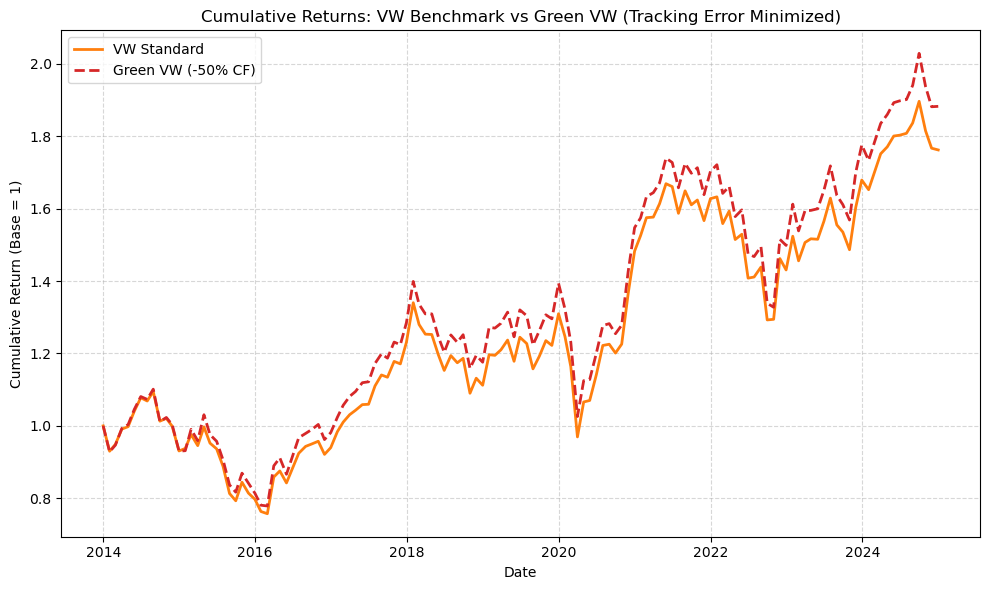

In [20]:
tracking_weights_dict = {}

for year in range(2014, 2025):
    prev_year = year - 1
    isins = filtered_carbon_isin_dict[year]
    N = len(isins)

    E_i = co2_scope1.loc[isins, prev_year]
    Cap_i = mv_yearly.loc[isins, prev_year]

    c_vector = (E_i / Cap_i).fillna(0.0).values
    w_vw = (Cap_i.fillna(0.0) / Cap_i.fillna(0.0).sum()).values
    cf_target = 0.5 * cf_vw[year]

    Sigma_psd_np = prepare_covariance(covariance_matrices[year], lambda_shrink)

    w = cp.Variable(N)
    objective = cp.Minimize(cp.quad_form(w - w_vw, cp.psd_wrap(Sigma_psd_np)))
    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        c_vector @ w <= cf_target
    ]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=False)

    if prob.status in ("optimal", "optimal_inaccurate"):
        weights = pd.Series(w.value, index=isins)
        weights = weights.clip(lower=0)
        weights /= weights.sum()
        tracking_weights_dict[year] = weights
        cf_achieved = np.dot(c_vector, weights.values)
        print(f"{year} -> CF {cf_achieved:.2f}, limit {cf_target:.2f}")
    else:
        print(f"{year}: solver failed ({prob.status})")

weights_te_df = pd.DataFrame(tracking_weights_dict).fillna(0.0)

# ex-post simulation
portfolio_returns_te = []

for year in range(2014, 2025):
    w = weights_te_df[year].copy()
    w = w.reindex(returns.index).fillna(0.0)
    w /= w.sum()
    months = [dt for dt in returns.columns if dt.year == year]
    for t in sorted(months):
        r_t = returns[t].reindex(w.index).fillna(0.0)
        R_p = np.dot(w.values, r_t.values)
        portfolio_returns_te.append((t, R_p))
        w = w * (1 + r_t) / (1 + R_p)
        w /= w.sum()

pf_ret_vw_c = pd.Series(
    [ret for (_, ret) in portfolio_returns_te],
    index=[dt for (dt, _) in portfolio_returns_te],
    name="Green_VW_ExPost_Returns"
)

rf_series_te = rf.shift(1).reindex(pf_ret_vw_c.index)

ann_return_vw_c = ((1 + pf_ret_vw_c).prod()) ** (12 / len(pf_ret_vw_c)) - 1
sigma_monthly_vw_c = pf_ret_vw_c.std(ddof=1)
ann_volatility_vw_c = sigma_monthly_vw_c * np.sqrt(12)
excess_ret_vw_c = pf_ret_vw_c - rf_series_te
ann_sharpe_vw_c = (excess_ret_vw_c.mean() / sigma_monthly_vw_c) * np.sqrt(12)

comp_vw_df = pd.DataFrame({
    "VW Standard P(vw)": [ann_return_vw, ann_volatility_vw, ann_sharpe_vw],
    "Green VW P(vw 0.5)": [ann_return_vw_c, ann_volatility_vw_c, ann_sharpe_vw_c]
}, index=["Annualized Return", "Annualized Volatility", "Sharpe Ratio"])
fmt_vw_df = comp_vw_df.copy().astype(object)
for col in fmt_vw_df.columns:
    fmt_vw_df[col] = [
        f"{comp_vw_df[col].iloc[0]:.3%}",
        f"{comp_vw_df[col].iloc[1]:.3%}",
        f"{comp_vw_df[col].iloc[2]:.3f}"
    ]
print(fmt_vw_df)

cumret_vw_c = pd.concat([pd.Series({pd.Timestamp("2013-12-31"): 1.0}), (1 + pf_ret_vw_c).cumprod()])

plt.figure(figsize=(10, 6))
plt.plot(cumret_vw.index, cumret_vw.values, label="VW Standard", color='tab:orange', linewidth=2)
plt.plot(cumret_vw_c.index, cumret_vw_c.values, label="Green VW (-50% CF)", color='tab:red', linewidth=2, linestyle='--')
plt.title("Cumulative Returns: VW Benchmark vs Green VW (Tracking Error Minimized)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Base = 1)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 3.4 Comparison of the Four Portfolios

The four strategies differ in their objective and carbon constraint: $P^{mv}$ minimizes variance with no constraint, $P^{mv}_{0.5}$ minimizes variance with CF $\leq$ 50% of $\mathrm{CF}^{mv}$, $P^{vw}$ is cap-weighted with no constraint, and $P^{vw}_{0.5}$ minimizes tracking error with CF $\leq$ 50% of $\mathrm{CF}^{vw}$. Comparing each green portfolio to its unconstrained counterpart shows the performance cost of the carbon constraint.

                      P(mv) Standard P(mv) Green (-50%) P(vw) Standard  \
Annualized Return             5.562%             5.458%         5.284%   
Annualized Volatility         9.816%             9.748%        16.043%   
Sharpe Ratio                   0.500              0.462          0.358   

                      P(vw) Green (-50%)  
Annualized Return                 5.918%  
Annualized Volatility            16.610%  
Sharpe Ratio                       0.393  


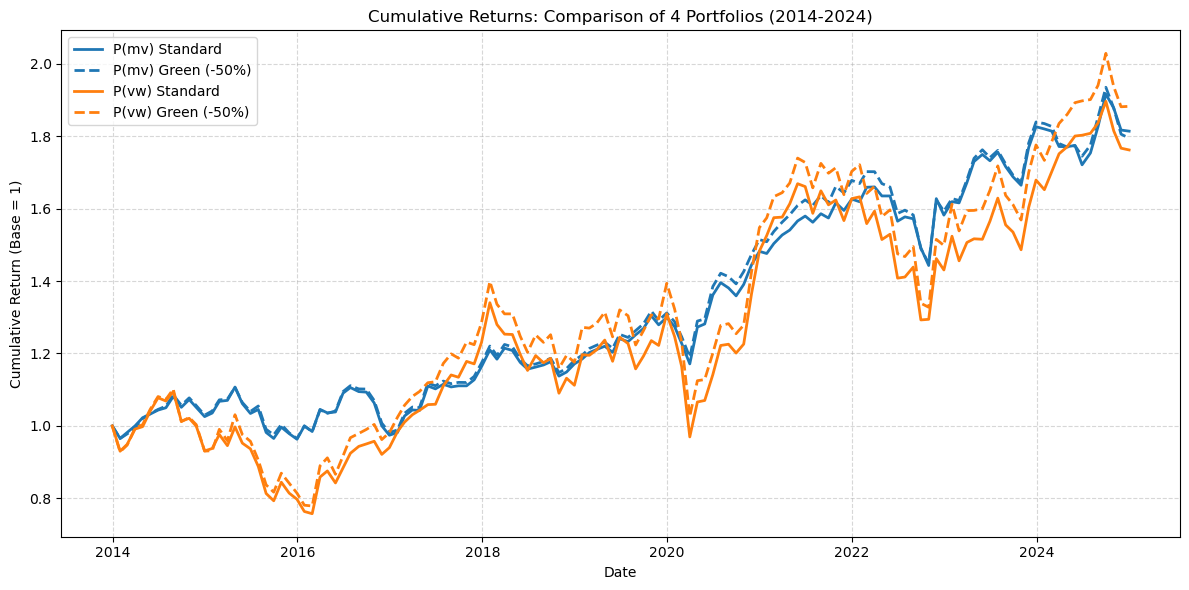

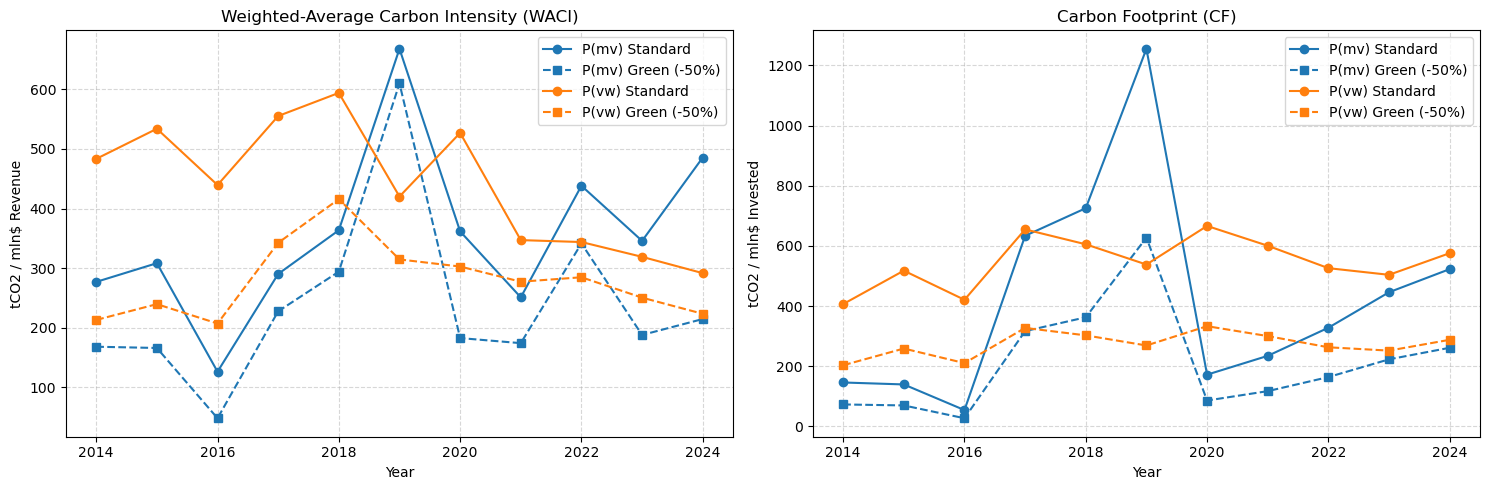

In [21]:
# carbon metrics for the green VW portfolio
waci_vw_c, cf_vw_c = {}, {}

for year in range(2014, 2025):
    prev_year = year - 1
    isins = filtered_carbon_isin_dict[year]
    w_te = weights_te_df.loc[isins, year]
    E_i = co2_scope1.loc[isins, prev_year]
    Rev_i = revenues.loc[isins, prev_year] / 1000.0
    Cap_i = mv_yearly.loc[isins, prev_year]
    CI_i = (E_i / Rev_i).replace([np.inf, -np.inf], np.nan)
    waci_vw_c[year] = (w_te * CI_i).sum()
    cf_vw_c[year] = (w_te * (E_i / Cap_i)).sum()

waci_vw_c = pd.Series(waci_vw_c)
cf_vw_c = pd.Series(cf_vw_c)

summary_34_df = pd.DataFrame({
    "P(mv) Standard": [ann_return, ann_volatility, ann_sharpe],
    "P(mv) Green (-50%)": [ann_return_c, ann_volatility_c, ann_sharpe_c],
    "P(vw) Standard": [ann_return_vw, ann_volatility_vw, ann_sharpe_vw],
    "P(vw) Green (-50%)": [ann_return_vw_c, ann_volatility_vw_c, ann_sharpe_vw_c]
}, index=["Annualized Return", "Annualized Volatility", "Sharpe Ratio"])
fmt_summary_34 = summary_34_df.copy().astype(object)
for col in fmt_summary_34.columns:
    fmt_summary_34[col] = [
        f"{summary_34_df[col].iloc[0]:.3%}",
        f"{summary_34_df[col].iloc[1]:.3%}",
        f"{summary_34_df[col].iloc[2]:.3f}"
    ]
print(fmt_summary_34)

plt.figure(figsize=(12, 6))
plt.plot(cumret_mvp.index, cumret_mvp.values, label="P(mv) Standard", color='tab:blue', linewidth=2)
plt.plot(cumret_mvp_c.index, cumret_mvp_c.values, label="P(mv) Green (-50%)", color='tab:blue', linewidth=2, linestyle='--')
plt.plot(cumret_vw.index, cumret_vw.values, label="P(vw) Standard", color='tab:orange', linewidth=2)
plt.plot(cumret_vw_c.index, cumret_vw_c.values, label="P(vw) Green (-50%)", color='tab:orange', linewidth=2, linestyle='--')
plt.title("Cumulative Returns: Comparison of 4 Portfolios (2014-2024)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Base = 1)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(waci_mvp.index, waci_mvp.values, label='P(mv) Standard', color='tab:blue', marker='o')
axes[0].plot(waci_mvp_c.index, waci_mvp_c.values, label='P(mv) Green (-50%)', color='tab:blue', marker='s', linestyle='--')
axes[0].plot(waci_vw.index, waci_vw.values, label='P(vw) Standard', color='tab:orange', marker='o')
axes[0].plot(waci_vw_c.index, waci_vw_c.values, label='P(vw) Green (-50%)', color='tab:orange', marker='s', linestyle='--')
axes[0].set_title('Weighted-Average Carbon Intensity (WACI)')
axes[0].set_ylabel('tCO2 / mln$ Revenue')
axes[0].set_xlabel('Year')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(cf_mvp.index, cf_mvp.values, label='P(mv) Standard', color='tab:blue', marker='o')
axes[1].plot(cf_mvp_c.index, cf_mvp_c.values, label='P(mv) Green (-50%)', color='tab:blue', marker='s', linestyle='--')
axes[1].plot(cf_vw.index, cf_vw.values, label='P(vw) Standard', color='tab:orange', marker='o')
axes[1].plot(cf_vw_c.index, cf_vw_c.values, label='P(vw) Green (-50%)', color='tab:orange', marker='s', linestyle='--')
axes[1].set_title('Carbon Footprint (CF)')
axes[1].set_ylabel('tCO2 / mln$ Invested')
axes[1].set_xlabel('Year')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 4. Portfolio Allocation with a Net Zero Objective

### 4.1 Net Zero Portfolio

The net zero strategy tightens the carbon budget each year by 10% relative to the 2013 baseline:

$$\mathrm{CF}_{\text{target}}(Y) = (1 - \theta)^{Y - 2013} \times \mathrm{CF}^{VW}_{2014}, \qquad \theta = 0.10$$

The target is 90% of the baseline in 2014, roughly 53% in 2019, and around 31% in 2024. This path is consistent with a Paris-aligned decarbonization trajectory. The optimization problem is the same as in Section 3.3, but the carbon budget tightens every year.

In [22]:
net_zero_weights_dict = {}
theta = 0.10

cf_base = cf_vw[2014]  # base CF from 2013

for year in range(2014, 2025):
    prev_year = year - 1
    isins = filtered_carbon_isin_dict[year]
    N = len(isins)

    E_i = co2_scope1.loc[isins, prev_year]
    Cap_i = mv_yearly.loc[isins, prev_year]

    c_vector = (E_i / Cap_i).fillna(0.0).values
    w_vw = (Cap_i.fillna(0.0) / Cap_i.fillna(0.0).sum()).values

    # budget shrinks by 10% each year relative to 2013
    cf_target = ((1 - theta) ** (year - 2013)) * cf_base

    Sigma_psd_np = prepare_covariance(covariance_matrices[year], lambda_shrink)

    w = cp.Variable(N)
    objective = cp.Minimize(cp.quad_form(w - w_vw, cp.psd_wrap(Sigma_psd_np)))
    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        c_vector @ w <= cf_target
    ]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=False)

    if prob.status in ("optimal", "optimal_inaccurate"):
        weights = pd.Series(w.value, index=isins)
        weights = weights.clip(lower=0)
        weights /= weights.sum()
        net_zero_weights_dict[year] = weights
        cf_achieved = np.dot(c_vector, weights.values)
        print(f"{year}: CF = {cf_achieved:.2f} / budget = {cf_target:.2f}")
    else:
        print(f"{year}: no solution ({prob.status})")

weights_nz_df = pd.DataFrame(net_zero_weights_dict).fillna(0.0)
portfolio_returns_nz = []

for year in range(2014, 2025):
    w = weights_nz_df[year].copy()
    w = w.reindex(returns.index).fillna(0.0)
    w /= w.sum()
    months = [dt for dt in returns.columns if dt.year == year]
    for t in sorted(months):
        r_t = returns[t].reindex(w.index).fillna(0.0)
        R_p = np.dot(w.values, r_t.values)
        portfolio_returns_nz.append((t, R_p))
        w = w * (1 + r_t) / (1 + R_p)
        w /= w.sum()

pf_ret_vw_nz = pd.Series(
    [ret for (_, ret) in portfolio_returns_nz],
    index=[dt for (dt, _) in portfolio_returns_nz],
    name="NetZero_VW_ExPost_Returns"
)

2014: CF = 366.04 / budget = 366.04
2015: CF = 329.44 / budget = 329.44
2016: CF = 296.49 / budget = 296.49
2017: CF = 266.84 / budget = 266.84
2018: CF = 240.16 / budget = 240.16
2019: CF = 216.14 / budget = 216.14
2020: CF = 194.53 / budget = 194.53
2021: CF = 175.08 / budget = 175.08
2022: CF = 157.57 / budget = 157.57
2023: CF = 141.81 / budget = 141.81
2024: CF = 127.63 / budget = 127.63


### 4.2 Comparison of the VW Portfolios

The three value-weighted strategies are compared on the same performance metrics. Since the net zero constraint becomes tighter each year, the deviation from the unconstrained benchmark grows over time, reflecting the increasing cost of the decarbonization path.

                      P(vw) Standard P(vw) Green (-50%)  \
Annualized Return             5.284%             5.918%   
Annualized Volatility        16.043%            16.610%   
Sharpe Ratio                   0.358              0.393   

                      P(vw) Net Zero (-10%/yr)  
Annualized Return                       5.999%  
Annualized Volatility                  16.647%  
Sharpe Ratio                             0.397  


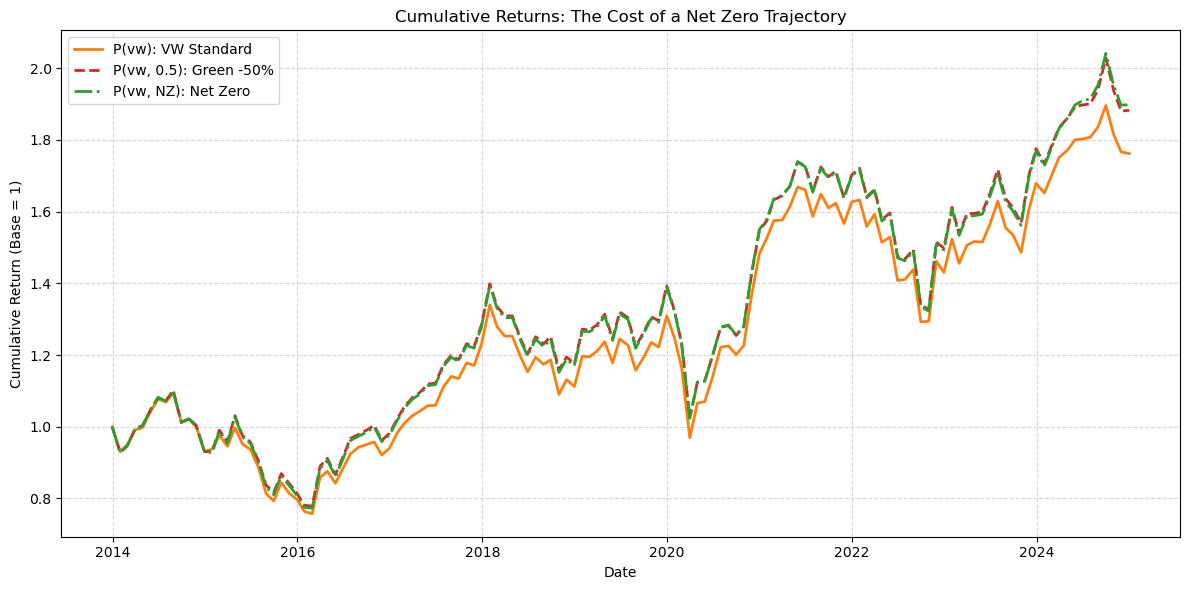

In [23]:
rf_series_nz = rf.shift(1).reindex(pf_ret_vw_nz.index)
ann_return_vw_nz = ((1 + pf_ret_vw_nz).prod()) ** (12 / len(pf_ret_vw_nz)) - 1
sigma_monthly_vw_nz = pf_ret_vw_nz.std(ddof=1)
ann_volatility_vw_nz = sigma_monthly_vw_nz * np.sqrt(12)
excess_ret_vw_nz = pf_ret_vw_nz - rf_series_nz
ann_sharpe_vw_nz = (excess_ret_vw_nz.mean() / sigma_monthly_vw_nz) * np.sqrt(12)

comp_42_df = pd.DataFrame({
    "P(vw) Standard": [ann_return_vw, ann_volatility_vw, ann_sharpe_vw],
    "P(vw) Green (-50%)": [ann_return_vw_c, ann_volatility_vw_c, ann_sharpe_vw_c],
    "P(vw) Net Zero (-10%/yr)": [ann_return_vw_nz, ann_volatility_vw_nz, ann_sharpe_vw_nz]
}, index=["Annualized Return", "Annualized Volatility", "Sharpe Ratio"])

fmt_42_df = comp_42_df.copy().astype(object)
for col in fmt_42_df.columns:
    fmt_42_df[col] = [
        f"{comp_42_df[col].iloc[0]:.3%}",
        f"{comp_42_df[col].iloc[1]:.3%}",
        f"{comp_42_df[col].iloc[2]:.3f}"
    ]
print(fmt_42_df)

cumret_vw_nz = pd.concat([pd.Series({pd.Timestamp("2013-12-31"): 1.0}), (1 + pf_ret_vw_nz).cumprod()])

plt.figure(figsize=(12, 6))
plt.plot(cumret_vw.index, cumret_vw.values, label="P(vw): VW Standard", color="tab:orange", linewidth=2)
plt.plot(cumret_vw_c.index, cumret_vw_c.values, label="P(vw, 0.5): Green -50%", color="tab:red", linewidth=2, linestyle="--")
plt.plot(cumret_vw_nz.index, cumret_vw_nz.values, label="P(vw, NZ): Net Zero", color="tab:green", linewidth=2, linestyle="-.")
plt.title("Cumulative Returns: The Cost of a Net Zero Trajectory")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Base = 1)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
